In [4]:
uper=int(input('En'))
for num in range(2,uper):
    for i in range(2,num):
        if num%i==0:
            break
    else:
        print(num)

En40
2
3
5
7
11
13
17
19
23
29
31
37


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [6]:
job = pd.read_csv("C:/Users/acer/Downloads/Job_Placement_Data.csv")
job.head()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


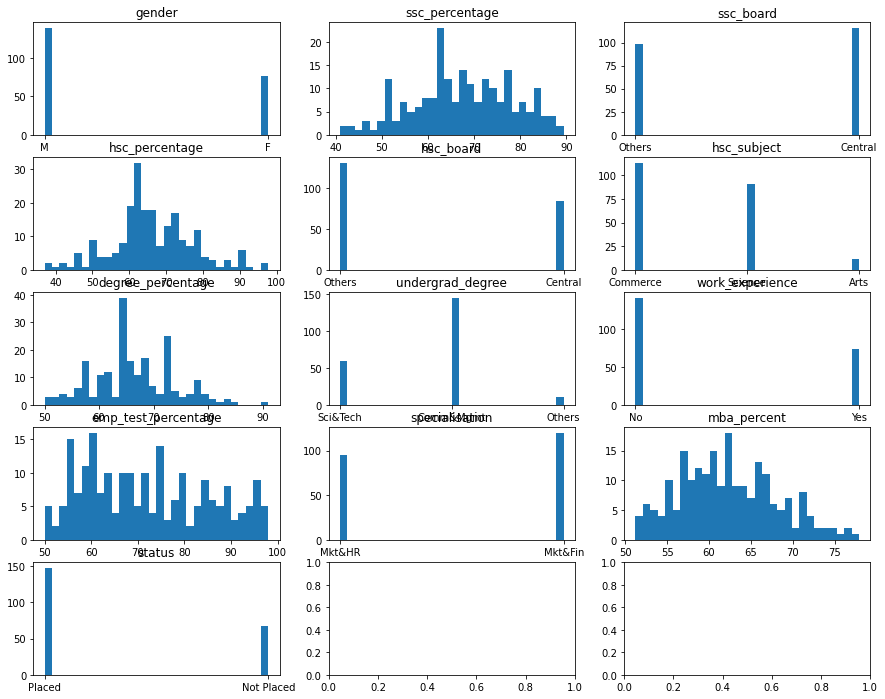

In [20]:
fig,ax=plt.subplots(5,3,figsize=(15,12))
cols=job.columns
a=0
for i in range(5):
    for j in range(3):
        ax[i][j].hist(job[cols[a]],bins=30)
        ax[i][j].title.set_text(cols[a])
        a+=1
        if a==13:
            break

In [29]:
lst=[ 'ssc_percentage',  'hsc_percentage', 'degree_percentage', 'emp_test_percentage'
       ,'mba_percent']

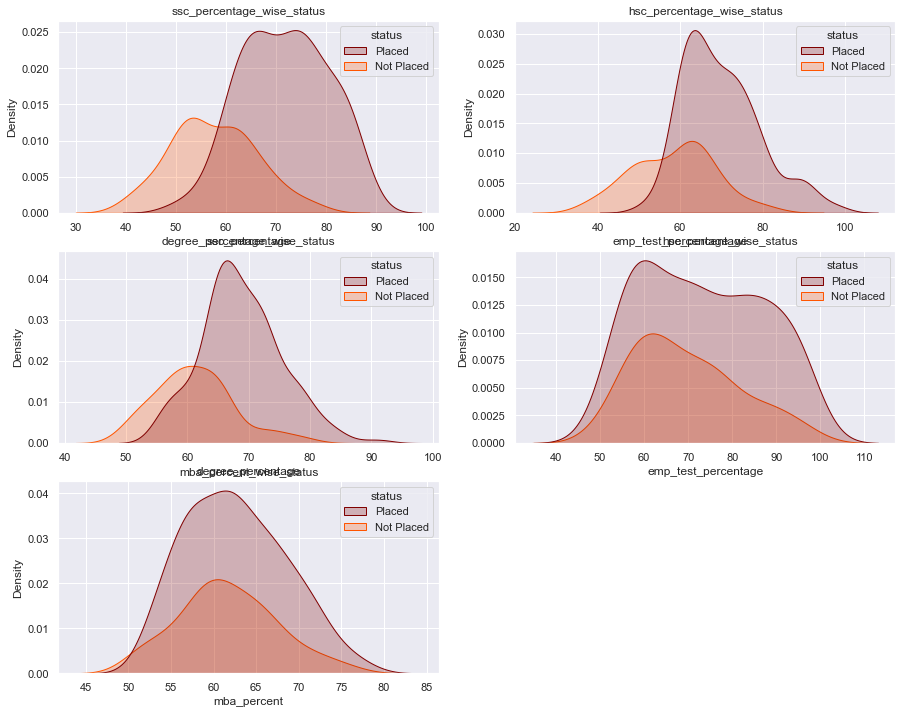

In [30]:
plt.figure(figsize=(15,12))
for i in range(0,len(lst)):
    plt.subplot(3,2,i+1)
    plt.title(lst[i]+'_wise_status')
    sns.kdeplot(data=job,x=lst[i],hue='status',shade=True,palette='gist_heat')
plt.show()

In [32]:
cat=job.select_dtypes(exclude='number')
for i in list(cat.columns):
    print(job[i].value_counts())
    print(10*'#####')

M    139
F     76
Name: gender, dtype: int64
##################################################
Central    116
Others      99
Name: ssc_board, dtype: int64
##################################################
Others     131
Central     84
Name: hsc_board, dtype: int64
##################################################
Commerce    113
Science      91
Arts         11
Name: hsc_subject, dtype: int64
##################################################
Comm&Mgmt    145
Sci&Tech      59
Others        11
Name: undergrad_degree, dtype: int64
##################################################
No     141
Yes     74
Name: work_experience, dtype: int64
##################################################
Mkt&Fin    120
Mkt&HR      95
Name: specialisation, dtype: int64
##################################################
Placed        148
Not Placed     67
Name: status, dtype: int64
##################################################


In [33]:
from sklearn.preprocessing import LabelEncoder
l_encoder=LabelEncoder()
for i in list(cat.columns):
    job[i+'_encoder']=l_encoder.fit_transform(job[i])
job.head()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,...,mba_percent,status,gender_encoder,ssc_board_encoder,hsc_board_encoder,hsc_subject_encoder,undergrad_degree_encoder,work_experience_encoder,specialisation_encoder,status_encoder
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,...,58.80,Placed,1,1,1,1,2,0,1,1
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,...,66.28,Placed,1,0,1,2,2,1,0,1
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,...,57.80,Placed,1,0,0,0,0,0,0,1
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,...,59.43,Not Placed,1,0,0,2,2,0,1,0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,...,55.50,Placed,1,0,0,1,0,0,0,1


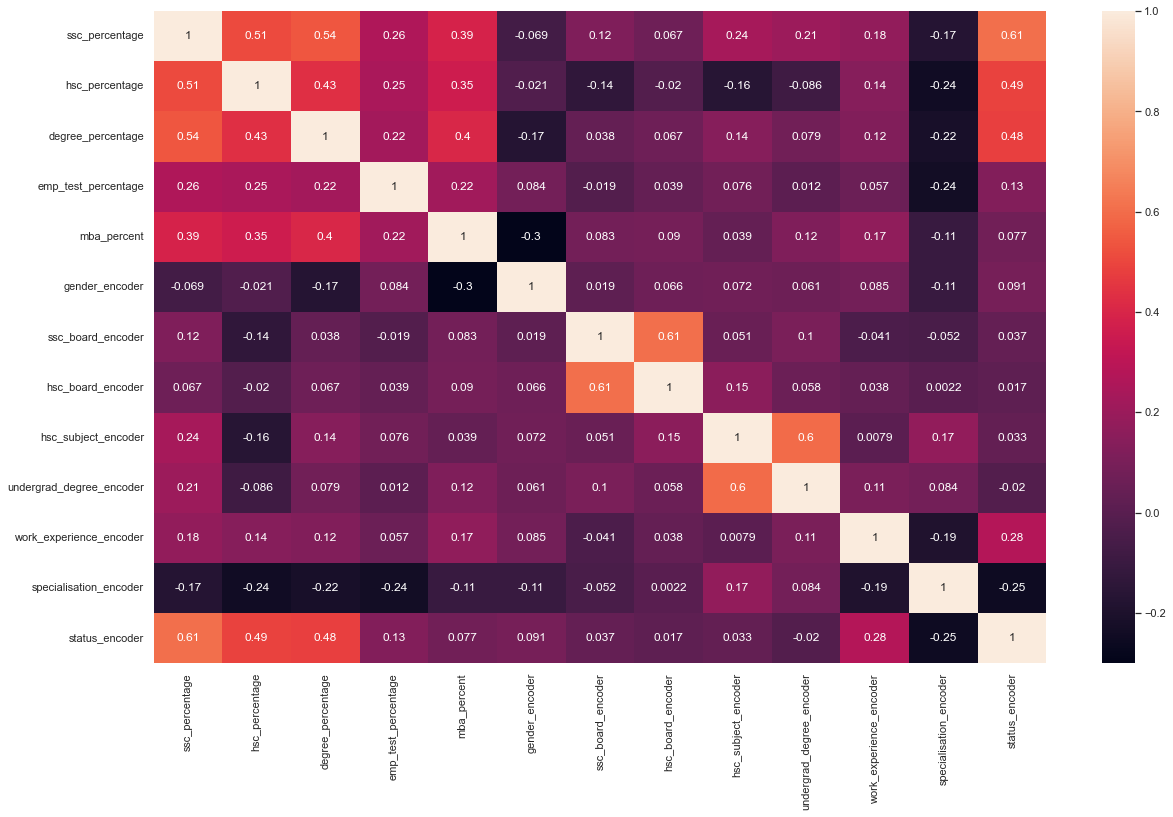

In [38]:
plt.figure(figsize=(20,12))
sns.heatmap(job.corr(),annot=True);

In [39]:
job.columns

Index(['gender', 'ssc_percentage', 'ssc_board', 'hsc_percentage', 'hsc_board',
       'hsc_subject', 'degree_percentage', 'undergrad_degree',
       'work_experience', 'emp_test_percentage', 'specialisation',
       'mba_percent', 'status', 'gender_encoder', 'ssc_board_encoder',
       'hsc_board_encoder', 'hsc_subject_encoder', 'undergrad_degree_encoder',
       'work_experience_encoder', 'specialisation_encoder', 'status_encoder'],
      dtype='object')

In [44]:
jobb=job[['ssc_percentage','hsc_percentage','degree_percentage',
 'emp_test_percentage','work_experience_encoder','specialisation_encoder','status_encoder']]

jobb.head()

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,work_experience_encoder,specialisation_encoder,status_encoder
0,67.00,91.00,58.00,55.0,0,1,1
1,79.33,78.33,77.48,86.5,1,0,1
2,65.00,68.00,64.00,75.0,0,0,1
3,56.00,52.00,52.00,66.0,0,1,0
4,85.80,73.60,73.30,96.8,0,0,1


In [47]:
X=jobb.drop('status_encoder',axis=1)
y=jobb[['status_encoder']]

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes  import GaussianNB
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.tree         import DecisionTreeClassifier
from sklearn.metrics      import accuracy_score,f1_score,classification_report,confusion_matrix
from sklearn.ensemble     import RandomForestClassifier,AdaBoostClassifier,StackingClassifier
import warnings
warnings.simplefilter(action='ignore')

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,
                                               random_state=1)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((150, 6), (65, 6), (150, 1), (65, 1))

In [122]:
def model_lr(X_train,X_test,y_train,y_test):
    global acc_lr,f1_lr
    lr=LogisticRegression()
    lr.fit(X_train,y_train)
    y_pred=lr.predict(X_test)
    
    acc_lr=accuracy_score(y_test,y_pred)
    f1_lr=f1_score(y_test,y_pred)
    print('Accuracy Score:',acc_lr)
    print('f1-Score:',f1_lr)
    print('Classification Report:',classification_report(y_test,y_pred))

In [123]:
model_lr(X_train,X_test,y_train,y_test)

Accuracy Score: 0.8153846153846154
f1-Score: 0.8723404255319148
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.60      0.67        20
           1       0.84      0.91      0.87        45

    accuracy                           0.82        65
   macro avg       0.79      0.76      0.77        65
weighted avg       0.81      0.82      0.81        65



In [121]:
def model_nb(X_train,X_test,y_train,y_test):
    global acc_nb,f1_nb
    nb=GaussianNB()
    nb.fit(X_train,y_train)
    y_pred=nb.predict(X_test)
    
    acc_nb=accuracy_score(y_test,y_pred)
    f1_nb=f1_score(y_test,y_pred)
    print('Accuracy Score:',acc_nb)
    print('f1-Score:',f1_nb)
    print('Classification Report:',classification_report(y_test,y_pred))

In [79]:
model_nb(X_train,X_test,y_train,y_test)

Accuracy Score: 0.8615384615384616
f1-Score: 0.8615384615384616
Classification Report:               precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.91      0.89      0.90        45

    accuracy                           0.86        65
   macro avg       0.84      0.84      0.84        65
weighted avg       0.86      0.86      0.86        65



In [119]:
def model_tr(X_train,X_test,y_train,y_test):
    global acc_tr,f1_tr
    tr=DecisionTreeClassifier()
    tr.fit(X_train,y_train)
    y_pred=tr.predict(X_test)
    
    acc_tr=accuracy_score(y_test,y_pred)
    f1_tr=f1_score(y_test,y_pred)
    print('Accuracy Score:',acc_tr)
    print('f1-Score:',f1_tr)
    print('Classification Report:',classification_report(y_test,y_pred))

In [120]:
model_tr(X_train, X_test, y_train, y_test)

Accuracy Score: 0.7538461538461538
f1-Score: 0.8260869565217391
Classification Report:               precision    recall  f1-score   support

           0       0.61      0.55      0.58        20
           1       0.81      0.84      0.83        45

    accuracy                           0.75        65
   macro avg       0.71      0.70      0.70        65
weighted avg       0.75      0.75      0.75        65



In [117]:
def model_knn(X_train,X_test,y_train,y_test):
    global acc_knn,f1_knn
    knn=KNeighborsClassifier()
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    
    acc_knn=accuracy_score(y_test,y_pred)
    f1_knn=f1_score(y_test,y_pred)
    print('Accuracy Score:',acc_knn)
    print('f1-Score:',f1_knn)
    print('Classification Report:',classification_report(y_test,y_pred))

In [118]:
model_knn(X_train,X_test,y_train,y_test)

Accuracy Score: 0.8307692307692308
f1-Score: 0.88659793814433
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.55      0.67        20
           1       0.83      0.96      0.89        45

    accuracy                           0.83        65
   macro avg       0.84      0.75      0.78        65
weighted avg       0.83      0.83      0.82        65



In [115]:
def model_rf(X_train,X_test,y_train,y_test):
    global acc_rf,f1_rf
    rf=RandomForestClassifier()
    rf.fit(X_train,y_train)
    y_pred=rf.predict(X_test)
    
    acc_rf=accuracy_score(y_test,y_pred)
    f1_rf=f1_score(y_test,y_pred)
    print('Accuracy Score:',acc_rf)
    print('f1-Score:',f1_rf)
    print('Classification Report:',classification_report(y_test,y_pred))

In [116]:
model_rf(X_train,X_test,y_train,y_test)

Accuracy Score: 0.8153846153846154
f1-Score: 0.8749999999999999
Classification Report:               precision    recall  f1-score   support

           0       0.79      0.55      0.65        20
           1       0.82      0.93      0.87        45

    accuracy                           0.82        65
   macro avg       0.80      0.74      0.76        65
weighted avg       0.81      0.82      0.80        65



In [134]:
def model_ada(X_train,X_test,y_train,y_test):
    global acc_ada,f1_ada
    ada=AdaBoostClassifier()
    ada.fit(X_train,y_train)
    y_pred=ada.predict(X_test)
    
    acc_ada=accuracy_score(y_test,y_pred)
    f1_ada=f1_score(y_test,y_pred)
    print('Accuracy Score:',acc_ada)
    print('f1-Score:',f1_ada)
    print('Classification Report:',classification_report(y_test,y_pred))

In [135]:
model_ada(X_train,X_test,y_train,y_test)

Accuracy Score: 0.7692307692307693
f1-Score: 0.8421052631578948
Classification Report:               precision    recall  f1-score   support

           0       0.67      0.50      0.57        20
           1       0.80      0.89      0.84        45

    accuracy                           0.77        65
   macro avg       0.73      0.69      0.71        65
weighted avg       0.76      0.77      0.76        65



In [124]:
def stacking():
    stack=[]
    stack.append(('LOG',LogisticRegression()))
    stack.append(('NB',GaussianNB()))
    stack.append(('DTC',DecisionTreeClassifier()))
    stack.append(('KNN',KNeighborsClassifier()))
    stack.append(('rf',RandomForestClassifier()))
    stack.append(('ada',AdaBoostClassifier()))
    meta_model=LogisticRegression()
    model=StackingClassifier(estimators=stack,final_estimator=meta_model)
    return model

In [125]:
def model_st(X_train,X_test,y_train,y_test):
    global acc_St_model,f1_St_model
    St_model=stacking()
    St_model.fit(X_train,y_train)
    y_pred=St_model.predict(X_test)
    
    acc_St_model=accuracy_score(y_test,y_pred)
    f1_St_model=f1_score(y_test,y_pred)
    print('Accuracy Score:',acc_St_model)
    print('f1-Score:',f1_St_model)
    print('Classification Report:',classification_report(y_test,y_pred))


In [126]:
model_st(X_train,X_test,y_train,y_test)

Accuracy Score: 0.8307692307692308
f1-Score: 0.8817204301075269
Classification Report:               precision    recall  f1-score   support

           0       0.76      0.65      0.70        20
           1       0.85      0.91      0.88        45

    accuracy                           0.83        65
   macro avg       0.81      0.78      0.79        65
weighted avg       0.83      0.83      0.83        65



In [136]:
table=pd.DataFrame()
table['Model']   =pd.Series(['Log','GassNB','DecsiTr','KNN','RNDF','ADA','STAC'])
table['F1-score']=pd.Series([f1_lr,f1_nb,f1_tr,f1_knn,f1_rf,f1_ada,f1_St_model])

In [138]:
table.sort_values(by='F1-score',ascending=False)

,Model,F1-score
3,KNN,0.886598
6,STAC,0.881720
4,RNDF,0.875000
0,Log,0.872340
1,GassNB,0.861538
5,ADA,0.842105
2,DecsiTr,0.826087
